In [1]:
import itertools 
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

from visualization import (
    bulk_vs_singlecell_matrix_viz,
    loop_heatmap_plots_real_data,
    super_plot_heatmaps_real_data,
    barplot_matches_nonmatches_na,
 )
from accuracy_functions import load_expected_matches_real_data, find_mismatches_real_data
from analysis_shared_functions import (
    parse_heatmap_matrix_hysys,
)

In [2]:
DATA_PATH = "../../data/output_data/" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = ["CrosscheckFingerprints", "HYSYS", "NGSCheckmate", "Vireo"]
read_depths = [0, 1, 10, 20, 30, 40]
datasets = ["hgsoc", "hgsoc-new", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Sample similarity heatmaps

Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 0...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 1...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 10...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 20...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 30...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 40...
Processing tool HYSYS, dataset hgsoc, read depth 0...
Processing tool HYSYS, dataset hgsoc, read depth 1...
Processing tool HYSYS, dataset hgsoc, read depth 10...
Processing tool HYSYS, dataset hgsoc, read depth 20...
Processing tool HYSYS, dataset hgsoc, read depth 30...
Processing tool HYSYS, dataset hgsoc, read depth 40...
Processing tool NGSCheckmate, dataset hgsoc, read depth 0...
Processing tool NGSCheckmate, dataset hgsoc, read depth 1...
Processing tool NGSCheckmate, dataset hgsoc, read depth 10...
Processing tool NGSCheckmate, dataset hgsoc, read depth 20

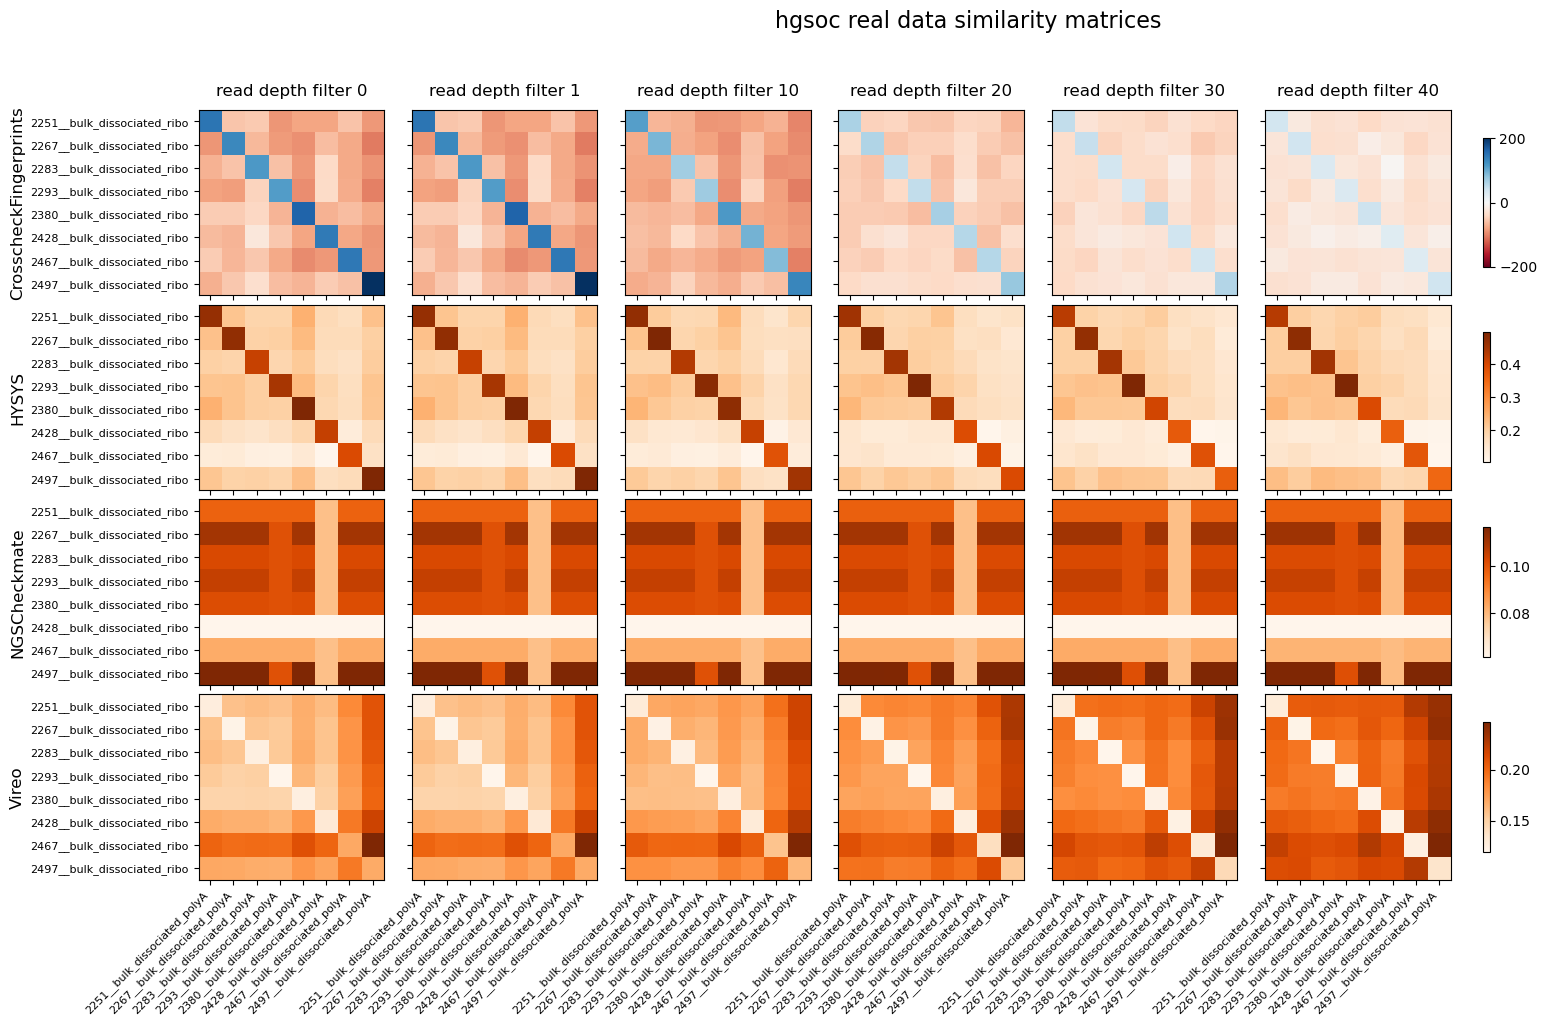

In [4]:
super_plot_heatmaps_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=tools,
    dataset="hgsoc",
    read_depths=read_depths,
    mod1="bulk_dissociated_ribo",
    mod2="bulk_dissociated_polyA",
    remove_missing_data=False,
    save_fig=False,
)

In [4]:
# To plot an individual heatmap instead use this function
bulk_vs_singlecell_matrix_viz(
    DATA_PATH=DATA_PATH,
    pseudobulk=False,
    tool="Vireo",
    dataset="hgsoc",
    ncells="null",
    rd="3_56",
    mod1="bulk_dissociated_polyA",
    mod2="single-cell",
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH   ,
)

Processing tool Vireo, dataset hgsoc, read depth 3_56...


In [5]:
from analysis_shared_functions import load_heatmap_data, order_matrix_by_expected_matches
matrix_df = load_heatmap_data(
        DATA_PATH, False, "Vireo", "hgsoc", "null", "3_56", "bulk_dissociated_polyA", "single-cell"
    )

Processing tool Vireo, dataset hgsoc, read depth 3_56...


In [6]:
expected_matches = load_expected_matches_real_data(DATA_PATH, "hgsoc")
sub_matrix = order_matrix_by_expected_matches(
    matrix_df,
    expected_matches,
    "bulk_dissociated_polyA",
    "single-cell",
)

In [7]:
sub_matrix

,2251_single_cell_single-cell,2267_single_cell_single-cell,2283_single_cell_single-cell,2293_single_cell_single-cell,2380_single_cell_single-cell,2428_single_cell_single-cell,2467_single_cell_single-cell,2497_single_cell_single-cell
2251_bulk_dissociated_polyA_bulk_dissociated_polyA,0.207982,0.209938,0.207206,0.208431,0.210979,0.203666,0.211123,0.210500
2267_bulk_dissociated_polyA_bulk_dissociated_polyA,0.195956,0.197696,0.194957,0.196005,0.198737,0.191427,0.198870,0.198297
2283_bulk_dissociated_polyA_bulk_dissociated_polyA,0.184208,0.185949,0.183134,0.184443,0.186993,0.179694,0.187120,0.186532
2293_bulk_dissociated_polyA_bulk_dissociated_polyA,0.187937,0.189523,0.186973,0.188213,0.190727,0.183413,0.190868,0.190296
2380_bulk_dissociated_polyA_bulk_dissociated_polyA,0.215890,0.217668,0.214951,0.216136,0.218530,0.211388,0.218854,0.218208
2428_bulk_dissociated_polyA_bulk_dissociated_polyA,0.174186,0.175920,0.173197,0.174462,0.176937,0.169559,0.177101,0.176489
2467_bulk_dissociated_polyA_bulk_dissociated_polyA,0.200770,0.202593,0.199840,0.201058,0.203580,0.196262,0.203493,0.203109
2497_bulk_dissociated_polyA_bulk_dissociated_polyA,0.248274,0.250037,0.247275,0.248508,0.250999,0.243737,0.251161,0.250361


In [10]:
# To plot multiple individual heatmaps use this function
loop_heatmap_plots_real_data(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH,
    tools=["Vireo", "HYSYS", "CrosscheckFingerprints"],
    datasets=["hgsoc"],
    read_depths=["3_25"],
    mod1="bulk_dissociated_polyA",
    mod2="single-cell",
)

Processing tool Vireo, dataset hgsoc, read depth 3_25...
Processing tool HYSYS, dataset hgsoc, read depth 3_25...
Processing tool CrosscheckFingerprints, dataset hgsoc, read depth 3_25...


# Comparison of inferred and expected sample matches

Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 1...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 10...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 20...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 30...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 40...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 1...
Processing tool HYSYS, dataset high_grade_glioma, read depth 10...
Processing tool HYSYS, dataset high_grade_glioma, read depth 20...
Processing tool HYSYS, dataset high_grade_glioma, read depth 30...
Processing tool HYSYS, dataset high_grade_glioma, read depth 40...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckm

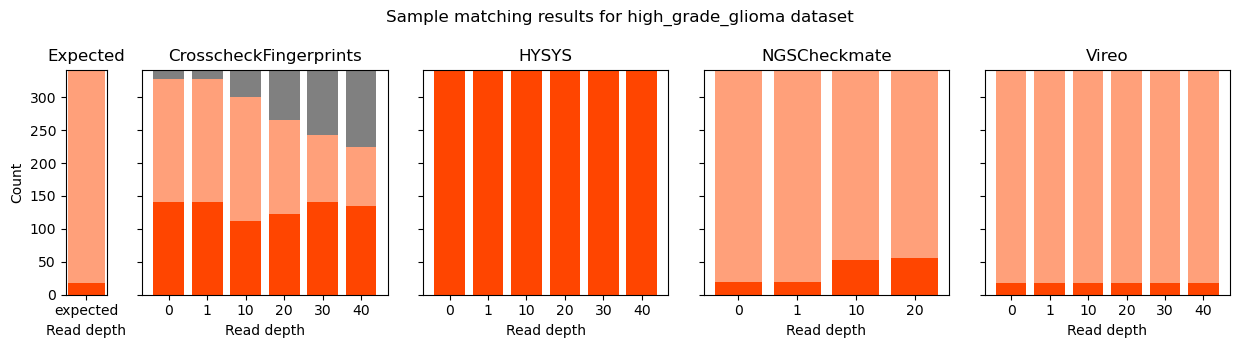

In [7]:
# Plot how many matches, non-matches, and NAs there are for each tool across read depths for a given dataset
barplot_matches_nonmatches_na(
    DATA_PATH=DATA_PATH, 
    tools=tools, 
    dataset="high_grade_glioma", 
    read_depths=read_depths, 
    mod1="bulk", 
    mod2="single-cell", 
    save_fig=False, 
    FIGURES_PATH=FIGURES_PATH
    )

In [4]:
merged_df = find_mismatches_real_data(
    DATA_PATH=DATA_PATH, 
    tool="NGSCheckmate", 
    dataset="high_grade_glioma", 
    read_depth=0, 
    mod1="bulk", 
    mod2="single-cell"
)
merged_df


Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...


,bulk,single-cell,sample_id_0,sample_id_1,modality_0,modality_1,match_status
0,GSM7305242,GSM7305260,GSM7305242,GSM7305260,bulk,single-cell,both
1,GSM7305243,GSM7305261,GSM7305243,GSM7305261,bulk,single-cell,both
2,GSM7305244,GSM7305262,GSM7305244,GSM7305262,bulk,single-cell,both
3,GSM7305245,GSM7305263,GSM7305245,GSM7305263,bulk,single-cell,both
4,GSM7305246,GSM7305264,NaN,NaN,NaN,NaN,left_only
5,NaN,NaN,GSM7305246,GSM7305268,bulk,single-cell,right_only
6,GSM7305247,GSM7305265,GSM7305247,GSM7305265,bulk,single-cell,both
7,GSM7305248,GSM7305266,GSM7305248,GSM7305266,bulk,single-cell,both
8,GSM7305249,GSM7305267,GSM7305249,GSM7305267,bulk,single-cell,both
9,GSM7305250,GSM7305268,NaN,NaN,NaN,NaN,left_only


# Combine HYSYS heatmap & Vireo algorithm

In [14]:
mod1 = "bulk"
mod2 = "single-cell"

In [15]:
_, hysys_matrix = parse_heatmap_matrix_hysys(
    DATA_PATH=DATA_PATH, 
    pseudobulk=False, 
    dataset="high_grade_glioma", 
    ncells="null",
    rd=0, 
    mod1=mod1, 
    mod2=mod2
)

In [ ]:
mod1_samples = [idx for idx in hysys_matrix.index if mod1 in idx]
mod2_samples = [col for col in hysys_matrix.columns if mod2 in col]
hysys_matrix = hysys_matrix.loc[mod1_samples, mod2_samples]

In [17]:
# Apply the linear sum assignment algorithm to find the optimal matching
idx0, idx1 = linear_sum_assignment(hysys_matrix.values, True)
matrix_reordered = pd.DataFrame(
    hysys_matrix.iloc[idx0, idx1],
    index=hysys_matrix.index[idx0],
    columns=hysys_matrix.columns[idx1],
)

In [18]:
# If there are more columns than rows (double samples),
# we need to add back the unmatched columns (these were inferred as non-matches)
if len(hysys_matrix.columns) > len(hysys_matrix.index):
    unmatched_cols = [
        col for col in mod2_samples if col not in matrix_reordered.columns
    ]
    for col in unmatched_cols:
        matrix_reordered[col] = 0
# If there are more rows than columns (missing samples),
# we need to add back the unmatched rows (these were inferred as non-matches)
elif len(hysys_matrix.index) > len(hysys_matrix.columns):
    unmatched_rows = [idx for idx in mod1_samples if idx not in matrix_reordered.index]
    for idx in unmatched_rows:
        matrix_reordered.loc[idx] = 0

In [19]:
matrix_reordered.shape

(18, 19)

In [20]:
hysys_matrix.shape

(18, 19)

In [ ]:
# Make sure the sample lists are the same length (padded with NaNs if necessary)
padded_lists = itertools.zip_longest(matrix_reordered.index, matrix_reordered.columns, fillvalue=np.nan)
mod1_samples, mod2_samples = zip(*padded_lists)

hysys_vireo_df = pd.DataFrame(
    {
        f"{mod1}": mod1_samples, 
        f"{mod2}": mod2_samples
    }
)

In [22]:
# Split the sample IDs into their components (e.g., "sample1_bulk" -> "sample1", "bulk")
hysys_vireo_df[["sample_id_0", "modality_0"]] = hysys_vireo_df[f"{mod1}"].str.rsplit("_", n=1, expand=True)
hysys_vireo_df[["sample_id_1", "modality_1"]] = hysys_vireo_df[f"{mod2}"].str.rsplit("_", n=1, expand=True)

expected_matches = load_expected_matches_real_data(DATA_PATH, "high_grade_glioma")

# Merge with expected matches to determine which inferred matches are correct
merged_df = expected_matches.merge(
    hysys_vireo_df,
    right_on=["sample_id_0", "sample_id_1"],
    left_on=[mod1, mod2],
    how="outer",
    indicator="match_status"
)

In [23]:
merged_df

,bulk_x,single-cell_x,bulk_y,single-cell_y,sample_id_0,modality_0,sample_id_1,modality_1,match_status
0,GSM7305242,GSM7305260,GSM7305242_bulk,GSM7305260_single-cell,GSM7305242,bulk,GSM7305260,single-cell,both
1,GSM7305243,GSM7305261,GSM7305243_bulk,GSM7305261_single-cell,GSM7305243,bulk,GSM7305261,single-cell,both
2,GSM7305244,GSM7305262,GSM7305244_bulk,GSM7305262_single-cell,GSM7305244,bulk,GSM7305262,single-cell,both
3,GSM7305245,GSM7305263,GSM7305245_bulk,GSM7305263_single-cell,GSM7305245,bulk,GSM7305263,single-cell,both
4,GSM7305246,GSM7305264,GSM7305246_bulk,GSM7305264_single-cell,GSM7305246,bulk,GSM7305264,single-cell,both
5,GSM7305247,GSM7305265,GSM7305247_bulk,GSM7305265_single-cell,GSM7305247,bulk,GSM7305265,single-cell,both
6,GSM7305248,GSM7305266,GSM7305248_bulk,GSM7305266_single-cell,GSM7305248,bulk,GSM7305266,single-cell,both
7,GSM7305249,GSM7305267,GSM7305249_bulk,GSM7305267_single-cell,GSM7305249,bulk,GSM7305267,single-cell,both
8,GSM7305250,GSM7305268,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,NaN,NaN,GSM7305250_bulk,GSM7305277_single-cell,GSM7305250,bulk,GSM7305277,single-cell,right_only
